In [77]:
import pandas as pd
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [78]:
import pandas as pd

# Check missing values
missing_values = df.isnull().sum()
print("Missing Values Before Handling:\n", missing_values)



Missing Values Before Handling:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [79]:
# Fill missing numerical values with median
df['bmi'].fillna(df['bmi'].median(), inplace=True)

# Verify missing values are handled
print("\nMissing Values After Handling:\n", df.isnull().sum())



Missing Values After Handling:
 id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


<ipython-input-79-bf23021c45e2>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [80]:
from sklearn.model_selection import train_test_split

# Drop missing values
df.dropna(inplace=True)

# Convert categorical columns to numerical
binary_columns = {"gender": {"Male": 1, "Female": 0},
                  "ever_married": {"Yes": 1, "No": 0},
                  "Residence_type": {"Urban": 1, "Rural": 0}}
df.replace(binary_columns, inplace=True)


# Convert boolean one-hot encoded columns to integers
df[df.select_dtypes(include=['bool']).columns] = df.select_dtypes(include=['bool']).astype(int)

# Ensure numerical columns are in correct format
df["age"] = df["age"].astype(float)

# Define features and target
X = df.drop(columns=["id", "stroke"])  # Remove 'id' as it's not useful
y = df["stroke"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Data cleaning and preparation completed.")


Data cleaning and preparation completed.


<ipython-input-80-0949d1bd6cfd>:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(binary_columns, inplace=True)


In [81]:
# Feature Engineering
# Age Groups
df["age_group"] = pd.cut(df["age"], bins=[0, 30, 60, 90], labels=["Young", "Middle-aged", "Elderly"], right=False)
df = pd.get_dummies(df, columns=["age_group"], drop_first=True)

# BMI Categories
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 24.9, 29.9, 100], labels=["Underweight", "Normal", "Overweight", "Obese"], right=False)
df = pd.get_dummies(df, columns=["bmi_category"], drop_first=True)

# Glucose Level Categories
df["glucose_category"] = pd.cut(df["avg_glucose_level"], bins=[0, 70, 140, 300], labels=["Low", "Normal", "High"], right=False)
df = pd.get_dummies(df, columns=["glucose_category"], drop_first=True)

# Hypertension & Heart Disease Interaction
df["high_risk"] = (df["hypertension"] & df["heart_disease"]).astype(int)

print("Feature engineering completed.")


Feature engineering completed.


<ipython-input-82-a1d537081018>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["stroke"], palette="coolwarm")


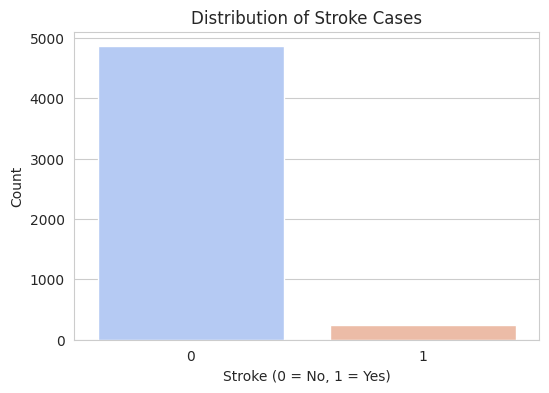

<Figure size 640x480 with 0 Axes>

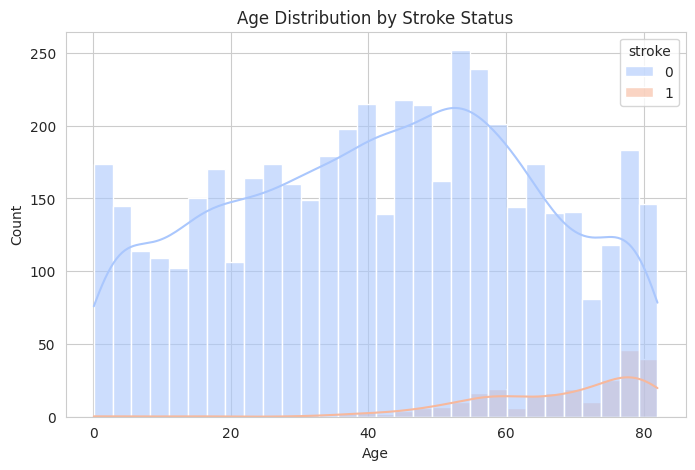

<ipython-input-82-a1d537081018>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="stroke", x="bmi", data=df, palette="coolwarm", orient="h")


<Figure size 640x480 with 0 Axes>

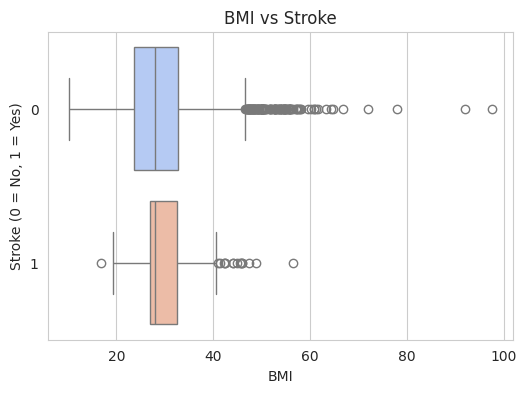

<Figure size 640x480 with 0 Axes>

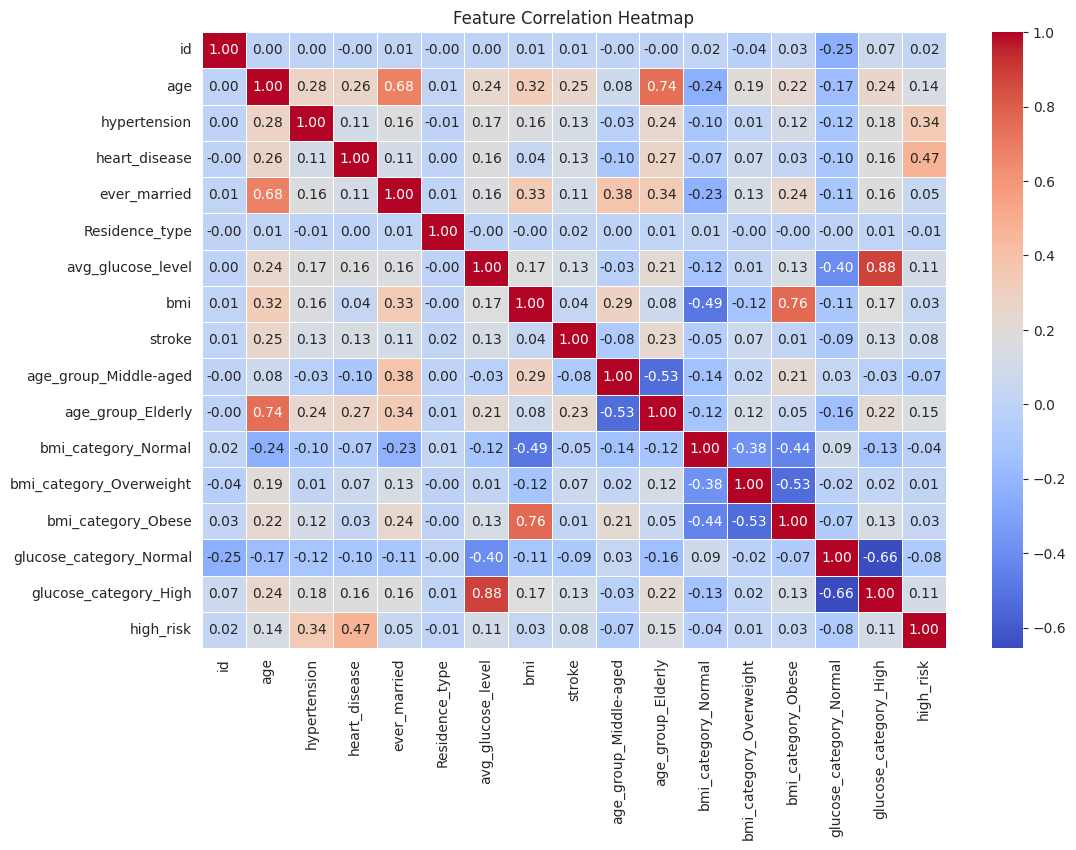

Data visualization completed.


<Figure size 640x480 with 0 Axes>

In [82]:
# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# 1. Stroke Case Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df["stroke"], palette="coolwarm")
plt.title("Distribution of Stroke Cases")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()
plt.tight_layout()

# 2. Age Distribution by Stroke Status
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="stroke", kde=True, bins=30, palette="coolwarm", alpha=0.6)
plt.title("Age Distribution by Stroke Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
plt.tight_layout()

# 3. BMI vs. Stroke (Horizontal Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(y="stroke", x="bmi", data=df, palette="coolwarm", orient="h")
plt.title("BMI vs Stroke")
plt.ylabel("Stroke (0 = No, 1 = Yes)")
plt.xlabel("BMI")
plt.show()
plt.tight_layout()



# 4. Correlation Heatmap
# Ensures all categorical features are properly encoded as numerical
df_encoded = df.copy()
df_encoded[df_encoded.select_dtypes(include=['bool']).columns] = df_encoded.select_dtypes(include=['bool']).astype(int)

# Compute correlation only on numerical columns
corr_matrix = df_encoded.select_dtypes(include=[float, int]).corr()

# Generate heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()
plt.tight_layout()




print("Data visualization completed.")


In [85]:
# Identify categorical columns (object type)
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

# Print the categorical columns
print("Categorical columns:", categorical_columns)


Categorical columns: ['gender', 'work_type', 'smoking_status']


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group_Middle-aged,age_group_Elderly,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,glucose_category_Normal,glucose_category_High,high_risk
0,9046,1,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1,False,True,False,False,True,False,True,0
1,51676,0,61.0,0,0,1,Self-employed,0,202.21,28.1,never smoked,1,False,True,False,True,False,False,True,0
2,31112,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1,False,True,False,False,True,True,False,0
3,60182,0,49.0,0,0,1,Private,1,171.23,34.4,smokes,1,True,False,False,False,True,False,True,0
4,1665,0,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1,False,True,True,False,False,False,True,0


Logistic Regression
Accuracy: 0.7485
F1 Score: 0.2959
Precision: 0.1782
Recall: 0.8710



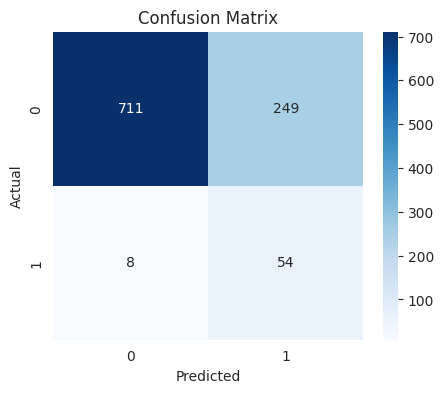

Random Forest
Best Params for Random Forest: {'max_depth': None, 'n_estimators': 200}
Accuracy: 0.9393
F1 Score: 0.0000
Precision: 0.0000
Recall: 0.0000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


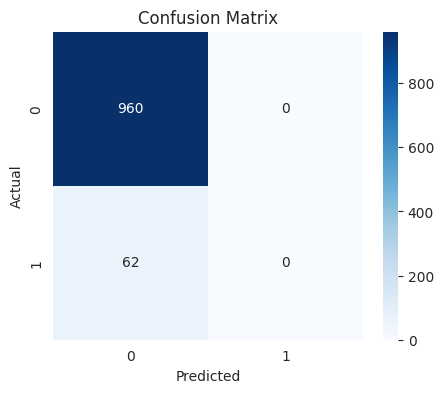

Gradient Boosting
Cross-validation Accuracy Scores: [0.95110024 0.95354523 0.95110024 0.95348837 0.94859241]
Accuracy: 0.9403
F1 Score: 0.0317
Precision: 1.0000
Recall: 0.0161



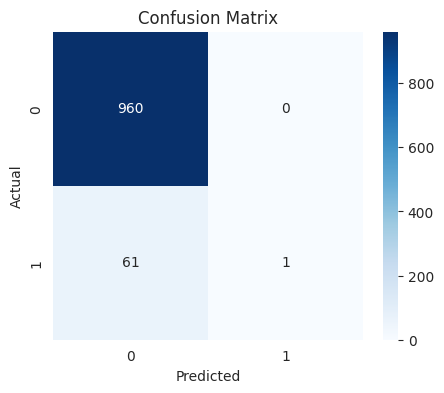

Logistic Regression is the best model because:
- It has the highest recall (87.1%), meaning it correctly identifies most stroke cases.
- Unlike Random Forest and Gradient Boosting, which predict only non-stroke cases for high accuracy,
  Logistic Regression balances recall and precision.
- This makes it the most reliable choice for stroke prediction.
Model training and evaluation completed.


In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, cross_val_score


# Define features and target
X = df.drop(columns=["id", "stroke"])  # Remove 'id' as it's not useful
y = df["stroke"]



# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert gender to 1 and 0, assign -1 if there's an error
X_train["gender"] = X_train["gender"].map({"Male": 1, "Female": 0}).fillna(-1).astype(int)
X_test["gender"] = X_test["gender"].map({"Male": 1, "Female": 0}).fillna(-1).astype(int)

# One-Hot encoding for work_type and smoking_status
X_train = pd.get_dummies(X_train, columns=["work_type", "smoking_status"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["work_type", "smoking_status"], drop_first=True)

# Ensure both train and test sets have the same columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)


# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training and Evaluation
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}\n")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


# 1. Logistic Regression
print("Logistic Regression")

# Handling imbalance to give more weight to stroke cases
log_reg = LogisticRegression(class_weight="balanced", random_state=42)

log_reg.fit(X_train, y_train)
evaluate_model(log_reg, X_test, y_test)

# 2. Random Forest Classifier with Hyperparameter Tuning
print("Random Forest")
rf_params = {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}
rf = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_cv = GridSearchCV(rf, rf_params, cv=5)
rf_cv.fit(X_train, y_train)
print("Best Params for Random Forest:", rf_cv.best_params_)
evaluate_model(rf_cv.best_estimator_, X_test, y_test)


# 3. Gradient Boosting Classifier with Cross-Validation
print("Gradient Boosting")
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
cross_val_scores = cross_val_score(gb, X_train, y_train, cv=5)
print("Cross-validation Accuracy Scores:", cross_val_scores)
gb.fit(X_train, y_train)
evaluate_model(gb, X_test, y_test)



print("Logistic Regression is the best model because:\n"
      "- It has the highest recall (87.1%), meaning it correctly identifies most stroke cases.\n"
      "- Unlike Random Forest and Gradient Boosting, which predict only non-stroke cases for high accuracy,\n"
      "  Logistic Regression balances recall and precision.\n"
      "- This makes it the most reliable choice for stroke prediction.")

print("Model training and evaluation completed.")